# Spatial visualisation of biomass at the time of the contaminant injection

In [1]:
import os
import xarray as xr
import numpy as np
import geopandas as gpd
from pathlib import Path
from PIL import Image
import glob
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
from shapely.geometry import Point
import ssam_groups as groups
from IPython.display import Image as im
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [37]:
file_id = int(input( ))
scenario = {1 : "5b",
            2 : "6a",
            3 : "7a",
            4 : "4a",}

print("\nScenario running  :", scenario[file_id], sep = " ")


Scenario running  : 5b


In [38]:
scen_path = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/')
scens = sorted([p for p in scen_path.glob('highres-2019-2022_'+str(scenario[file_id])+'*/outputSalishSea.nc')])
scens

[PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/highres-2019-2022_5b_1_2019-01-20/outputSalishSea.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/highres-2019-2022_5b_2_2019-01-14/outputSalishSea.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/highres-2019-2022_5b_3_2020-01-24/outputSalishSea.nc'),
 PosixPath('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/highres-2019-2022_5b_4_2020-01-16/outputSalishSea.nc')]

In [39]:
if '4a' in scenario[file_id]:
    scenario_code = 'AP-'
    hex_colour = '#863092'           
elif '5b' in scenario[file_id]:
    scenario_code = 'TP-'
    hex_colour = '#6DB48E'
elif '6a' in scenario[file_id]:
    scenario_code = 'EB-'
    hex_colour = '#2F61A4'
elif '7a' in scenario[file_id]:
    scenario_code = 'JF-'
    hex_colour = '#A27170'

print(scenario_code, hex_colour)

TP- #6DB48E


In [6]:
# salish sea atlantis box shapefile.
shapefile_name = "/ocean/rlovindeer/Atlantis/ssam_oceanparcels/SalishSea/SalishSea_July172019_2/SalishSea_July172019.shp"
data_df_original = gpd.read_file(shapefile_name)
data_df_original = data_df_original.sort_values(by=['BOX_ID'])
data_df = data_df_original.set_index('BOX_ID')
box_depth = data_df['BOTZ']
box_area = data_df['AREA']
land_boxes = box_depth==0
land_boxes = data_df.index[land_boxes]

In [36]:
def plot_spatial_numbers(variable_name, scens=scens, start=1, end=5):
    _cmap = cm.Blues
    land_df = data_df.loc[land_boxes]

    fig = plt.figure(figsize=(14, 6), facecolor='white') #figsize=(9, 12)
    gs = plt.GridSpec(1, 4, wspace=0.5, hspace=0.5, height_ratios=[1],)

    for path in scens:
        sim_code = str(path).split(sep = '_')[3]
        label = scenario_code+str(groups.conditions_with_letters[sim_code])
        position = int(sim_code)-1
        ax = fig.add_subplot(gs[0, position])
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=-0.5)
        pfile = xr.open_dataset(str(path), decode_cf=True)
        scenario = pfile.variables[groups.longname[variable_name]+'3_Nums'][start:end][:]
        scenario = scenario.sum(dim='z').mean(dim='t')
        data_df[variable_name] = scenario
        #data_df.plot(column = 'vertmix', cmap=_cmap, ax=ax, vmin=0, vmax = 10, legend=False,)
        data_df.plot(column = variable_name, cmap=_cmap, ax=ax, cax=cax,
            legend_kwds={'label': 'Number of '+variable_name}, legend = True)
        land_df.plot(ax=ax, color='white')

        ax.set_title(label, fontsize = 14) #loc='left'
        ax.set_xlim(-124.5)
        ax.set_ylim(48, 50)
        data_df.boundary.plot(ax=ax, color='grey', linewidths=0.5)

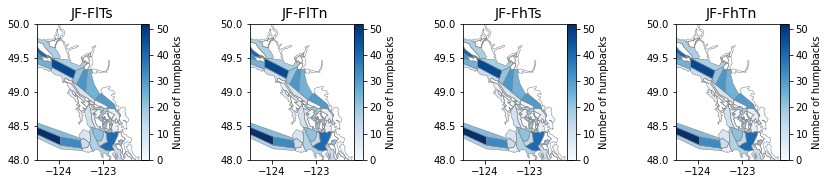

In [35]:
plot_spatial_numbers('humpbacks') # number of cohort 3

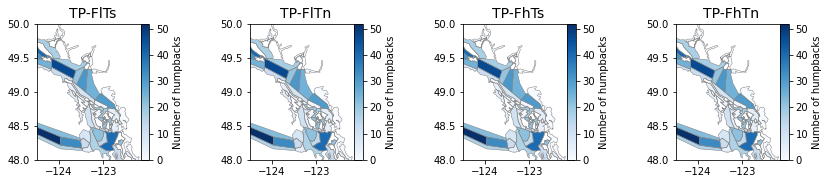

In [40]:
plot_spatial_numbers('humpbacks') # number of cohort 3

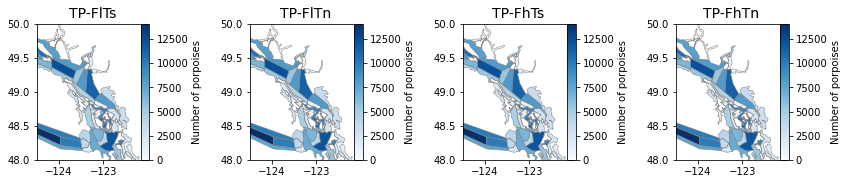

In [41]:
plot_spatial_numbers('porpoises') # number of cohort 3